In [6]:
# Cell 1 — Data Loading
import os
import pandas as pd
import glob
import sys; sys.path.append("/scratch/gpfs/nb0564/vlm_reasoning")

# Path to output directory (where model results are)
output_root = "/scratch/gpfs/nb0564/vlm_reasoning/output"

# Find all CSV files recursively in output/
csv_files = glob.glob(os.path.join(output_root, "**/*.csv"), recursive=True)

# Load and concatenate all output data
df_list = []
for csv_file in csv_files:
    try:
        df = pd.read_csv(csv_file)
        # Add metadata from path
        path_parts = csv_file.split("/")
        task = path_parts[-3]  # e.g., 'glyphs', 'nuts_and_bolts', 'totems'
        model = path_parts[-2]  # e.g., 'gemini-flash'
        filename = path_parts[-1]  # e.g., 'glyphs_dim1_var0_dim2.csv'
        df['task'] = task
        df['model'] = model
        df['filename'] = filename
        
        # Derive missing columns expected by plotting code
        df['logical_dim'] = df['n_dimensions']  # logical_dim = n_dimensions
        df['var'] = df['reference_variance']     # var = reference_variance
        df['correct'] = (df['answer'] == df['oddball_idx']).astype(int)  # 1 if correct, 0 otherwise
        
        df_list.append(df)
    except Exception as e:
        print(f"Error loading {csv_file}: {e}")

if df_list:
    df_trials = pd.concat(df_list, ignore_index=True)
    print(f"Loaded {len(df_trials)} total trial rows from {len(csv_files)} files.")
    print(f"Columns: {list(df_trials.columns)}")
    print(f"Unique tasks: {sorted(df_trials['task'].unique())}")
    print(f"Logical dims: {sorted(df_trials['logical_dim'].unique())}")
    print(f"Vars: {sorted(df_trials['var'].unique())}")
    print(f"Accuracy: {df_trials['correct'].mean():.3f}")
else:
    df_trials = pd.DataFrame()
    print("No data loaded.")

Loaded 900 total trial rows from 36 files.
Columns: ['trial_idx', 'summary_path', 'oddball_idx', 'oddball_abstraction', 'reference_variance', 'n_dimensions', 'abstraction_columns', 'response', 'answer', 'n_input_tokens', 'n_thought_tokens', 'n_output_tokens', 'task', 'model', 'filename', 'logical_dim', 'var', 'correct']
Unique tasks: ['glyphs', 'nuts_and_bolts', 'totems']
Logical dims: [1, 2, 3]
Vars: [0, 1, 2, 3, 4, 5]
Accuracy: 0.842


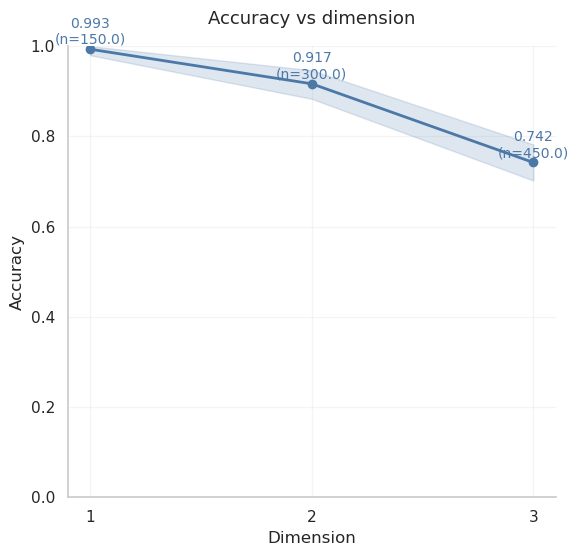

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

assert 'df_trials' in globals() and not df_trials.empty, "Run the data loading cell first."

# Aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (6, 6),
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
out_dir = "/scratch/gpfs/nb0564/vlm_reasoning/plots"
os.makedirs(out_dir, exist_ok=True)

def bootstrap_ci_mean(binary_series, n_boot=2000, alpha=0.05):
    a = binary_series.astype(int).values
    if a.size == 0:
        return np.nan, np.nan, np.nan
    boots = np.random.choice(a, size=(n_boot, a.size), replace=True).mean(axis=1)
    return float(a.mean()), float(np.percentile(boots, 100*alpha/2)), float(np.percentile(boots, 100*(1-alpha/2)))

# Aggregate across ALL variance levels at each logical dimension (concat all trials)
dims_present = sorted(df_trials['logical_dim'].unique())
rows = []
for ld in [1, 2, 3]:
    s = df_trials[df_trials['logical_dim'] == ld]['correct']
    if s.empty:
        continue
    m, lo, hi = bootstrap_ci_mean(s, n_boot=2000, alpha=0.05)
    rows.append((ld, m, lo, hi, len(s)))
P = pd.DataFrame(rows, columns=['logical_dim','mean','lo','hi','n']).sort_values('logical_dim')

# Plot
fig, ax = plt.subplots()

color = "#4C78A8"  # neutral journal-friendly blue
if not P.empty:
    ax.plot(P['logical_dim'], P['mean'], color=color, marker='o', lw=2)
    ax.fill_between(P['logical_dim'], P['lo'], P['hi'], color=color, alpha=0.18)
    for _, r in P.iterrows():
        ax.text(r['logical_dim'], r['mean'] + 0.012, f"{r['mean']:.3f}\n(n={r['n']})", ha='center', fontsize=10, color=color)

ax.set_title("Accuracy vs dimension", pad=16)
ax.set_xlabel("Dimension")
ax.set_ylabel("Accuracy")
ax.set_xticks([d for d in [1,2,3] if d in set(P['logical_dim'])])
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
sns.despine(ax=ax)

plt.tight_layout(pad=1.2, rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(out_dir, "acc_v_dim_agg.pdf"), bbox_inches="tight")
plt.show()

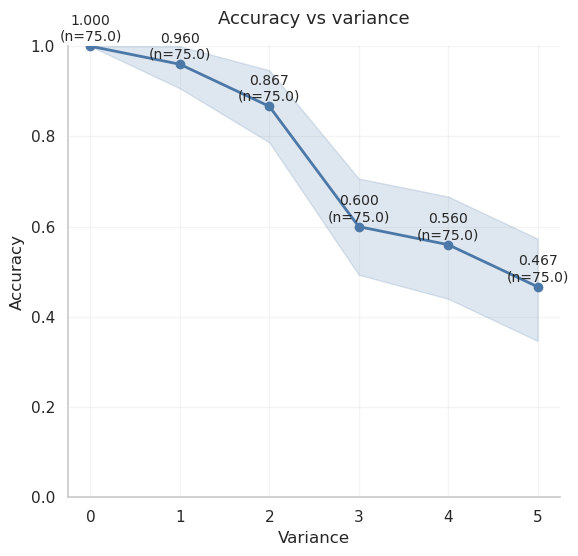

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

assert 'df_trials' in globals() and not df_trials.empty, "Run the data loading cell first."

# Style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (6, 6),
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
out_dir = "/scratch/gpfs/nb0564/vlm_reasoning/plots"
os.makedirs(out_dir, exist_ok=True)

def bootstrap_ci_mean(binary_series, n_boot=2000, alpha=0.05):
    a = binary_series.astype(int).values
    if a.size == 0:
        return np.nan, np.nan, np.nan
    boots = np.random.choice(a, size=(n_boot, a.size), replace=True).mean(axis=1)
    return float(a.mean()), float(np.percentile(boots, 100*alpha/2)), float(np.percentile(boots, 100*(1-alpha/2)))

# Fix logical dim to 3; fallback if missing
target_dim_for_var = 3 if (df_trials['logical_dim'] == 3).any() else int(df_trials['logical_dim'].max())

sub = df_trials[df_trials['logical_dim'] == target_dim_for_var]
pts = []
for v in sorted(sub['var'].unique()):
    ser = sub[sub['var'] == v]['correct']
    if ser.empty:
        continue
    m, lo, hi = bootstrap_ci_mean(ser, n_boot=2000, alpha=0.05)
    pts.append((v, m, lo, hi, len(ser)))
P = pd.DataFrame(pts, columns=['var','mean','lo','hi','n'])

# Plot
fig, ax = plt.subplots()
if not P.empty:
    neutral = "#4C78A8"
    ax.plot(P['var'], P['mean'], color=neutral, marker='o', lw=2)
    ax.fill_between(P['var'], P['lo'], P['hi'], color=neutral, alpha=0.18)
    for _, r in P.iterrows():
        ax.text(r['var'], r['mean'] + 0.012, f"{r['mean']:.3f}\n(n={r['n']})", ha='center', fontsize=10)
ax.set_title("Accuracy vs variance", pad=16)
ax.set_xlabel("Variance")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
sns.despine(ax=ax)
plt.tight_layout(pad=1.2, rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(out_dir, "acc_v_var.pdf"), bbox_inches="tight")
plt.show()

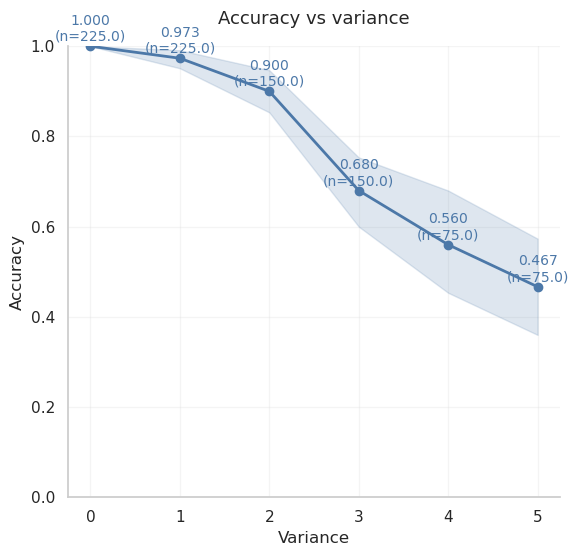

In [9]:
# Cell 3 — Accuracy vs variance aggregated across ALL dimensions (concatenate trials for each var)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

assert 'df_trials' in globals() and not df_trials.empty, "Run the data loading cell first."

# Aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (6, 6),
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
out_dir = "/scratch/gpfs/nb0564/vlm_reasoning/plots"
os.makedirs(out_dir, exist_ok=True)

def bootstrap_ci_mean(binary_series, n_boot=2000, alpha=0.05):
    a = binary_series.astype(int).values
    if a.size == 0:
        return np.nan, np.nan, np.nan
    boots = np.random.choice(a, size=(n_boot, a.size), replace=True).mean(axis=1)
    return float(a.mean()), float(np.percentile(boots, 100*alpha/2)), float(np.percentile(boots, 100*(1-alpha/2)))

# Aggregate across ALL logical dims at each variance
vars_sorted = sorted(df_trials['var'].unique())
rows = []
for v in vars_sorted:
    s = df_trials[df_trials['var'] == v]['correct']
    if s.empty:
        continue
    m, lo, hi = bootstrap_ci_mean(s, n_boot=2000, alpha=0.05)
    rows.append((v, m, lo, hi, len(s)))
P = pd.DataFrame(rows, columns=['var','mean','lo','hi','n']).sort_values('var')

# Plot
fig, ax = plt.subplots()
color = "#4C78A8"  # neutral, journal-friendly
if not P.empty:
    ax.plot(P['var'], P['mean'], color=color, marker='o', lw=2)
    ax.fill_between(P['var'], P['lo'], P['hi'], color=color, alpha=0.18)
    for _, r in P.iterrows():
        ax.text(r['var'], r['mean'] + 0.012, f"{r['mean']:.3f}\n(n={r['n']})", ha='center', fontsize=10, color=color)

ax.set_title("Accuracy vs variance", pad=16)
ax.set_xlabel("Variance")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
sns.despine(ax=ax)

plt.tight_layout(pad=1.2, rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(out_dir, "acc_v_var_agg.pdf"), bbox_inches="tight")
plt.show()

Recovered per-trial compression for 900 trials (missing program matches: 0, missing stats: 0)
Joined per-trial rows: 900
     task  logical_dim  var  trial_idx  trial_compression_ratio  trial_mdl  \
0  glyphs            1    0          0                18.333333        3.0   
1  glyphs            1    0          1                13.666667        3.0   
2  glyphs            1    0          2                13.666667        3.0   
3  glyphs            1    0          3                13.666667        3.0   
4  glyphs            1    0          4                18.333333        3.0   

   trial_accuracy  
0             1.0  
1             1.0  
2             1.0  
3             1.0  
4             1.0  


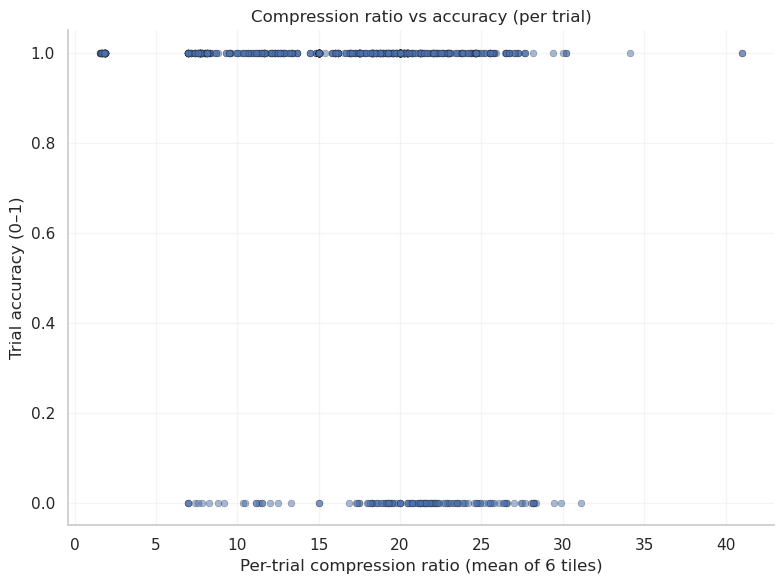

/tmp/ipykernel_813090/3459540577.py:162: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve = dfj.groupby("_bin_cr")["trial_accuracy"].agg(["mean", "count"]).reset_index()


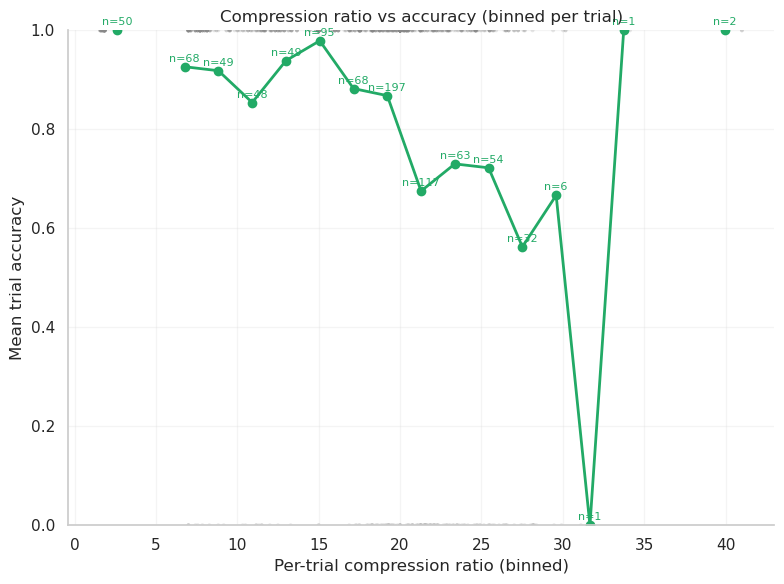

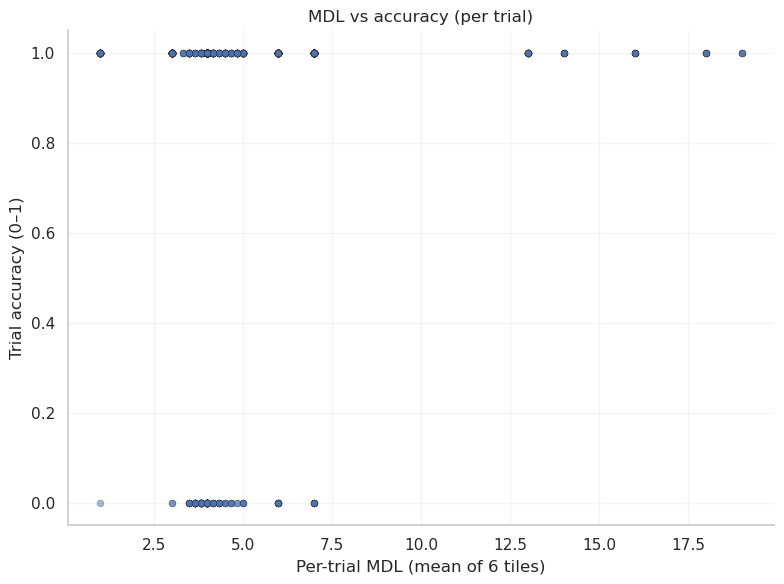

/tmp/ipykernel_813090/3459540577.py:190: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve_m = dfj.groupby("_bin_m")["trial_accuracy"].agg(["mean", "count"]).reset_index()


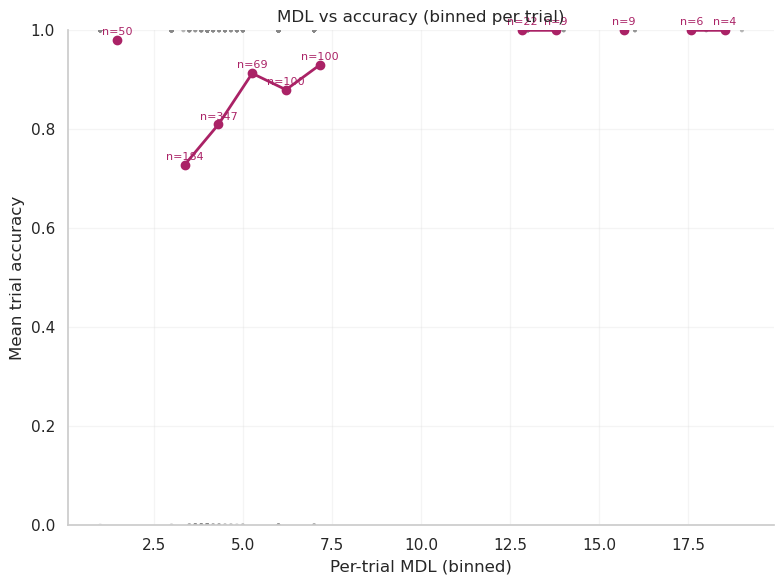

In [10]:
# Cell — Per-trial compression vs accuracy (robust, no task imports)
import os, json, hashlib, glob
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

# Paths
data_root = "/scratch/gpfs/nb0564/vlm_reasoning/data"
out_dir   = "/scratch/gpfs/nb0564/vlm_reasoning/plots"
os.makedirs(out_dir, exist_ok=True)

# 1) Load Stitch per-program results (supports merged or per-domain CSVs)
stitch_csvs = [
    os.path.join(data_root, "stitch_results_all.csv"),
    os.path.join(data_root, "stitch_results_glyphs.csv"),
    os.path.join(data_root, "stitch_results_nuts_and_bolts.csv"),
    os.path.join(data_root, "stitch_results_totems.csv"),
]
stitch_csvs = [p for p in stitch_csvs if os.path.exists(p)]
assert stitch_csvs, "No stitch results found. Run scripts/stitch.py first."

df_stitch = pd.concat([pd.read_csv(p) for p in stitch_csvs], ignore_index=True)
# Ensure stable_id exists; if missing, hash original_program
def sha1_prog(s: str) -> str:
    return hashlib.sha1((s or "").encode("utf-8")).hexdigest()

if "stable_id" not in df_stitch.columns:
    df_stitch["stable_id"] = df_stitch["original_program"].apply(sha1_prog)
else:
    need_sid = df_stitch["stable_id"].isna() | (df_stitch["stable_id"].astype(str) == "")
    df_stitch.loc[need_sid, "stable_id"] = df_stitch.loc[need_sid, "original_program"].apply(sha1_prog)

# Collapse duplicates by (task, stable_id) → mean metrics (ensures unique lookup)
df_prog = (
    df_stitch
    .groupby(["task", "stable_id"], as_index=False)[["compression_ratio", "mdl"]]
    .mean()
)

# Lookup: (task, stable_id) -> {compression_ratio, mdl}
prog_stats = {
    (row.task, row.stable_id): {"compression_ratio": row.compression_ratio, "mdl": row.mdl}
    for row in df_prog.itertuples(index=False)
}

# 2) Metadata loader and feature→program resolver
_meta_cache: dict[tuple, pd.DataFrame] = {}

def load_metadata(task: str, dim: int, var: int) -> pd.DataFrame:
    """Load metadata.csv for task/dim/var."""
    key = (task, dim, var)
    if key in _meta_cache:
        return _meta_cache[key]
    path = os.path.join(data_root, task, f"dim{dim}", f"var{var}", "metadata.csv")
    if not os.path.exists(path):
        _meta_cache[key] = pd.DataFrame()
        return _meta_cache[key]
    dfm = pd.read_csv(path)
    dfm.columns = [str(c) for c in dfm.columns]
    _meta_cache[key] = dfm
    return dfm

def program_from_features(task: str, dim: int, var: int, features: dict) -> str | None:
    """Find program_string by matching tile features to metadata row on overlapping columns."""
    dfm = load_metadata(task, dim, var)
    if dfm.empty or "program_string" not in dfm.columns:
        return None
    feat = {str(k): v for k, v in (features or {}).items()}
    # Overlapping keys excluding program_string and image paths
    cols = [c for c in dfm.columns if c in feat and c not in ("program_string", "render_filepath", "image_path")]
    if not cols:
        return None
    mask = pd.Series(True, index=dfm.index)
    for c in cols:
        mask &= (dfm[c].astype(str) == str(feat[c]))
    sub = dfm.loc[mask]
    if sub.empty:
        # Try categorical-only match (ignore numeric drift)
        cat_cols = [c for c in cols if not str(feat[c]).replace(".", "", 1).isdigit()]
        if cat_cols:
            mask = pd.Series(True, index=dfm.index)
            for c in cat_cols:
                mask &= (dfm[c].astype(str) == str(feat[c]))
            sub = dfm.loc[mask]
    if sub.empty:
        return None
    return str(sub.iloc[0]["program_string"])

# 3) Iterate all trials via trials.jsonl (do not depend on importing tasks)
def iter_trials():
    for task in ["glyphs", "nuts_and_bolts", "totems"]:
        troot = os.path.join(data_root, task)
        if not os.path.isdir(troot):
            continue
        for dim_dir in sorted(d for d in os.listdir(troot) if d.startswith("dim")):
            dim = int(dim_dir[3:])
            for var_dir in sorted(v for v in os.listdir(os.path.join(troot, dim_dir)) if v.startswith("var")):
                var = int(var_dir[3:])
                tj = os.path.join(troot, dim_dir, var_dir, "trials.jsonl")
                if not os.path.exists(tj):
                    continue
                with open(tj, "r") as f:
                    for line in f:
                        j = json.loads(line)
                        yield task, dim, var, int(j["trial_idx"]), j["tiles"]

# 4) Build per-trial compression by averaging the 6 tiles’ program compressions
rows = []
miss_prog, miss_stat = 0, 0
for task, dim, var, trial_idx, tiles in iter_trials():
    crs, mdls = [], []
    for tile in tiles:
        prog = program_from_features(task, dim, var, tile.get("features", {}))
        if not prog:
            miss_prog += 1
            continue
        sid = sha1_prog(prog)
        st = prog_stats.get((task, sid))  # domain-specific
        if not st:
            miss_stat += 1
            continue
        crs.append(float(st["compression_ratio"]))
        mdls.append(float(st["mdl"]))
    if crs:
        rows.append({
            "task": task, "logical_dim": dim, "var": var, "trial_idx": trial_idx,
            "trial_compression_ratio": float(np.mean(crs)),
            "trial_mdl": float(np.mean(mdls)) if mdls else np.nan,
        })

print(f"Recovered per-trial compression for {len(rows)} trials "
      f"(missing program matches: {miss_prog}, missing stats: {miss_stat})")
df_trial_comp = pd.DataFrame(rows)

# 5) Merge continuous trial accuracy from df_trials (assumes df_trials is already built in earlier cells)
acc = (
    df_trials
    .groupby(["task", "logical_dim", "var", "trial_idx"], as_index=False)["correct"]
    .mean()
    .rename(columns={"correct": "trial_accuracy"})
)
dfj = pd.merge(df_trial_comp, acc, on=["task", "logical_dim", "var", "trial_idx"], how="inner").dropna()

print("Joined per-trial rows:", len(dfj))
print(dfj.head())

# 6) Plots — raw scatter and binned trends
sns.set_theme(style="whitegrid")

# 6a) Compression ratio vs accuracy (raw)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dfj["trial_compression_ratio"], dfj["trial_accuracy"], s=24, alpha=0.5, edgecolors="k", linewidth=0.3)
ax.set_xlabel("Per-trial compression ratio (mean of 6 tiles)")
ax.set_ylabel("Trial accuracy (0–1)")
ax.set_title("Compression ratio vs accuracy (per trial)")
ax.grid(alpha=0.2); sns.despine(ax=ax)
plt.tight_layout(); plt.savefig(os.path.join(out_dir, "comp_ratio_vs_accuracy_per_trial_raw_meta.pdf"), bbox_inches="tight")
plt.show()

# 6b) Binned compression ratio curve
bins = np.linspace(dfj["trial_compression_ratio"].min(), dfj["trial_compression_ratio"].max(), 20)
dfj["_bin_cr"] = pd.cut(dfj["trial_compression_ratio"], bins=bins, include_lowest=True)
curve = dfj.groupby("_bin_cr")["trial_accuracy"].agg(["mean", "count"]).reset_index()
curve["x"] = curve["_bin_cr"].apply(lambda b: (b.left + b.right) / 2 if hasattr(b, "left") else np.nan)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dfj["trial_compression_ratio"], dfj["trial_accuracy"], s=8, alpha=0.2, color="#888", edgecolors="none")
ax.plot(curve["x"], curve["mean"], color="#2a6", lw=2, marker="o")
for _, r in curve.iterrows():
    if pd.notnull(r["x"]):
        ax.text(r["x"], r["mean"] + 0.01, f"n={int(r['count'])}", fontsize=8, ha="center", color="#2a6")
ax.set_xlabel("Per-trial compression ratio (binned)")
ax.set_ylabel("Mean trial accuracy")
ax.set_title("Compression ratio vs accuracy (binned per trial)")
ax.set_ylim(0, 1); ax.grid(alpha=0.2); sns.despine(ax=ax)
plt.tight_layout(); plt.savefig(os.path.join(out_dir, "comp_ratio_vs_accuracy_per_trial_binned_meta.pdf"), bbox_inches="tight")
plt.show()

# 6c) MDL vs accuracy (raw + binned)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dfj["trial_mdl"], dfj["trial_accuracy"], s=24, alpha=0.5, edgecolors="k", linewidth=0.3)
ax.set_xlabel("Per-trial MDL (mean of 6 tiles)")
ax.set_ylabel("Trial accuracy (0–1)")
ax.set_title("MDL vs accuracy (per trial)")
ax.grid(alpha=0.2); sns.despine(ax=ax)
plt.tight_layout(); plt.savefig(os.path.join(out_dir, "mdl_vs_accuracy_per_trial_raw_meta.pdf"), bbox_inches="tight")
plt.show()

bins_m = np.linspace(dfj["trial_mdl"].min(), dfj["trial_mdl"].max(), 20)
dfj["_bin_m"] = pd.cut(dfj["trial_mdl"], bins=bins_m, include_lowest=True)
curve_m = dfj.groupby("_bin_m")["trial_accuracy"].agg(["mean", "count"]).reset_index()
curve_m["x"] = curve_m["_bin_m"].apply(lambda b: (b.left + b.right) / 2 if hasattr(b, "left") else np.nan)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dfj["trial_mdl"], dfj["trial_accuracy"], s=8, alpha=0.2, color="#888", edgecolors="none")
ax.plot(curve_m["x"], curve_m["mean"], color="#a26", lw=2, marker="o")
for _, r in curve_m.iterrows():
    if pd.notnull(r["x"]):
        ax.text(r["x"], r["mean"] + 0.01, f"n={int(r['count'])}", fontsize=8, ha="center", color="#a26")
ax.set_xlabel("Per-trial MDL (binned)")
ax.set_ylabel("Mean trial accuracy")
ax.set_title("MDL vs accuracy (binned per trial)")
ax.set_ylim(0, 1); ax.grid(alpha=0.2); sns.despine(ax=ax)
plt.tight_layout(); plt.savefig(os.path.join(out_dir, "mdl_vs_accuracy_per_trial_binned_meta.pdf"), bbox_inches="tight")
plt.show()




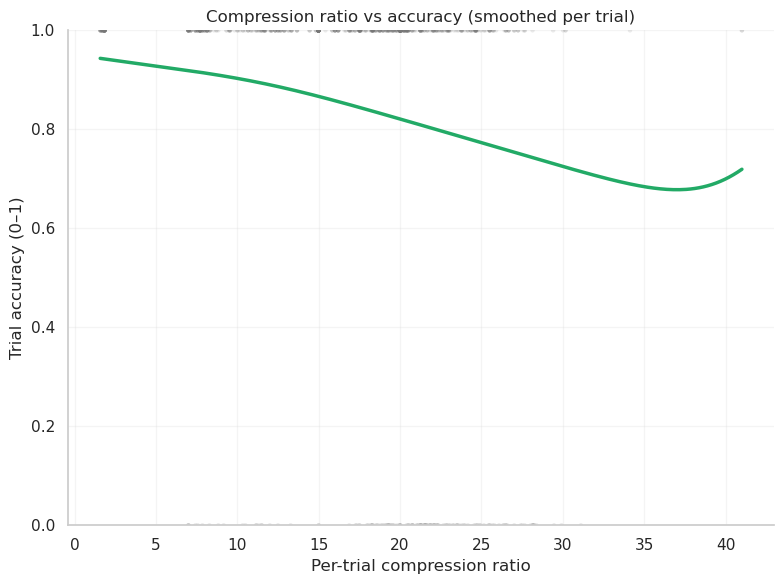

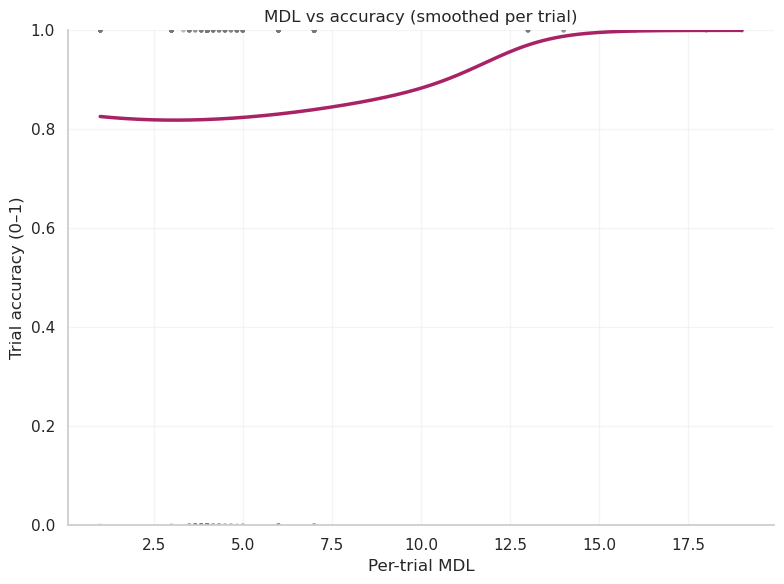

In [11]:
# Cell — Smooth curves for compression ratio/MDL vs accuracy (kernel/LOWESS)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    HAS_LOWESS = True
except Exception:
    HAS_LOWESS = False

def _kernel_smooth(x, y, xs, bandwidth):
    # Gaussian-kernel weighted mean
    x = np.asarray(x, float); y = np.asarray(y, float); xs = np.asarray(xs, float)
    bw = float(bandwidth) if bandwidth > 0 else (np.std(x) * (len(x) ** -0.2) + 1e-9)
    d = (xs[:, None] - x[None, :]) / (bw + 1e-12)
    w = np.exp(-0.5 * d * d)  # shape (len(xs), len(x))
    wsum = w.sum(axis=1) + 1e-12
    yhat = (w @ y) / wsum
    return np.clip(yhat, 0.0, 1.0)

def smooth_line(df, xcol, ycol, n_points=300, frac=0.15):
    # Build evenly spaced x grid
    x = df[xcol].values
    y = df[ycol].values
    xmin, xmax = float(np.min(x)), float(np.max(x))
    xs = np.linspace(xmin, xmax, n_points)

    if HAS_LOWESS:
        # LOWESS frac ~ smoothing window proportion of data
        lo = lowess(y, x, frac=frac, it=0, return_sorted=True)
        # Interpolate to xs for line continuity
        x_lo, y_lo = lo[:,0], lo[:,1]
        yhat = np.interp(xs, x_lo, y_lo)
    else:
        # Kernel smoother with bandwidth as a fraction of x-range
        bw = max(1e-9, frac * (xmax - xmin))
        yhat = _kernel_smooth(x, y, xs, bw)

    return xs, np.clip(yhat, 0.0, 1.0)

sns.set_theme(style="whitegrid")
out_dir = "/scratch/gpfs/nb0564/vlm_reasoning/plots"

# 1) Compression ratio vs accuracy (smooth)
xs, ys = smooth_line(dfj, "trial_compression_ratio", "trial_accuracy", n_points=300, frac=0.15)
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(dfj["trial_compression_ratio"], dfj["trial_accuracy"], s=10, alpha=0.15, color="#777", edgecolors="none")
ax.plot(xs, ys, color="#2a6", lw=2.5)
ax.set_xlabel("Per-trial compression ratio")
ax.set_ylabel("Trial accuracy (0–1)")
ax.set_title("Compression ratio vs accuracy (smoothed per trial)")
ax.set_ylim(0,1); ax.grid(alpha=0.2); sns.despine(ax=ax)
plt.tight_layout(); plt.savefig(f"{out_dir}/comp_ratio_vs_accuracy_per_trial_smooth.pdf", bbox_inches="tight")
plt.show()

# 2) MDL vs accuracy (smooth)
xs_m, ys_m = smooth_line(dfj, "trial_mdl", "trial_accuracy", n_points=300, frac=0.15)
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(dfj["trial_mdl"], dfj["trial_accuracy"], s=10, alpha=0.15, color="#777", edgecolors="none")
ax.plot(xs_m, ys_m, color="#a26", lw=2.5)
ax.set_xlabel("Per-trial MDL")
ax.set_ylabel("Trial accuracy (0–1)")
ax.set_title("MDL vs accuracy (smoothed per trial)")
ax.set_ylim(0,1); ax.grid(alpha=0.2); sns.despine(ax=ax)
plt.tight_layout(); plt.savefig(f"{out_dir}/mdl_vs_accuracy_per_trial_smooth.pdf", bbox_inches="tight")
plt.show()

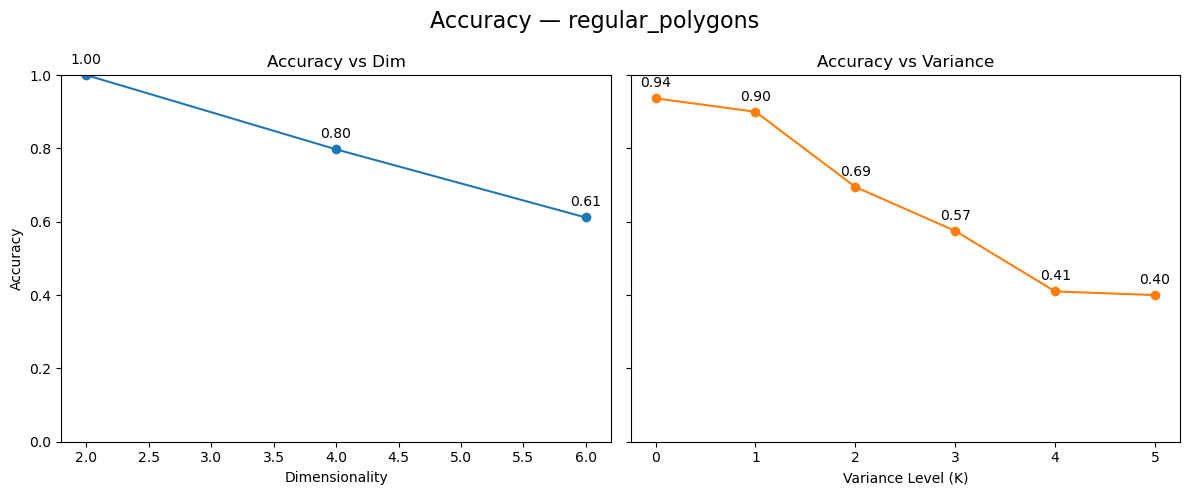

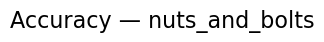

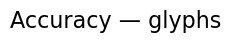

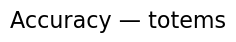

In [1]:
# Cell — Regular Polygons: Accuracy vs dim and variance
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
import glob

data_root = Path('/scratch/gpfs/nb0564/vlm_reasoning')
output_root = data_root / 'output'

# Helper to load accuracy per condition
def load_accuracy(task_name):
    records = []
    csv_pattern = output_root / 'None' / 'gemini-flash' / f"{task_name}_*.csv"
    for csv_path in glob.glob(str(csv_pattern)):
        df = pd.read_csv(csv_path)
        if df.empty:
            continue
        condition = csv_path.split('/')[-1].replace('.csv','')
        # Determine dim & var from filename
        dim = None
        var = None
        for token in condition.split('_'):
            if token.startswith('dim') and token[3:].isdigit():
                dim = int(token[3:])
            if token.startswith('var') and token[3:].isdigit():
                var = int(token[3:])
        correct = (df['oddball_idx'] == pd.to_numeric(df['answer'], errors='coerce')).sum()
        total = len(df)
        acc = correct / total if total else np.nan
        records.append(dict(task=task_name, condition=condition, dim=dim, var=var, accuracy=acc))
    return pd.DataFrame(records)

# Tasks to compare
tasks = {
    'regular_polygons': 'regular_polygons',
    'nuts_and_bolts': 'nab',
    'glyphs': 'glyphs',
    'totems': 'totems'
}

all_accuracy = []
for task_key, prefix in tasks.items():
    df = load_accuracy(prefix)
    if not df.empty:
        df['task'] = task_key
        all_accuracy.append(df)
all_accuracy = pd.concat(all_accuracy, ignore_index=True)

def plot_accuracy(data, task_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle(f'Accuracy — {task_name}', fontsize=16)
    sub = data[data['task'] == task_name]
    if sub.empty:
        axes[0].set_visible(False)
        axes[1].set_visible(False)
        return fig
    dim_pivot = sub.pivot_table(index='dim', values='accuracy', aggfunc='mean')
    axes[0].plot(dim_pivot.index, dim_pivot['accuracy'], marker='o')
    axes[0].set_title('Accuracy vs Dim')
    axes[0].set_xlabel('Dimensionality')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0,1)
    for dim, row in dim_pivot.iterrows():
        axes[0].annotate(f"{row['accuracy']:.2f}", (dim, row['accuracy']), textcoords='offset points', xytext=(0,8), ha='center')
    var_pivot = sub.pivot_table(index='var', values='accuracy', aggfunc='mean')
    axes[1].plot(var_pivot.index, var_pivot['accuracy'], marker='o', color='tab:orange')
    axes[1].set_title('Accuracy vs Variance')
    axes[1].set_xlabel('Variance Level (K)')
    axes[1].set_ylim(0,1)
    for var, row in var_pivot.iterrows():
        axes[1].annotate(f"{row['accuracy']:.2f}", (var, row['accuracy']), textcoords='offset points', xytext=(0,8), ha='center')
    plt.tight_layout()
    return fig

# Generate plots per task
for task in tasks:
    fig = plot_accuracy(all_accuracy, task)
    plt.show()